# 04 - V2 Data Cleaning and Processing Documentation

This notebook documents the cleaning and processing stage for the V2 Keepa dataset.

The raw data was previously explored in: `notebooks/03_v2_data_exploration.ipynb`

Based on that raw exploration, the processing script was updated to convert the raw Keepa JSON files into a cleaned daily dataset suitable for feature engineering and XGBoost model training.

The processing script used is: `src/data/reprocess_raw.py`

The script reads raw JSON files from: `data/raw/v2_raw/` and saves the cleaned dataset to: `data/processed/clean_data_v2.csv`

This notebook documents:
- the cleaning strategy
- the fields extracted from the raw JSON files
- how the selected modelling price was created
- how missing values and forward filling were handled
- which quality filters were applied
- what the final cleaned dataset looks like
- whether the processed data is suitable for the next feature engineering stage

In [7]:
# Cell 2 - Import Libraries and Set Display Options

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.colheader_justify", "left")

In [10]:
# Cell 3 - Load the Cleaned V2 Dataset and Verify Basic Processing Outputs

RAW_DIR = Path("../data/raw/v2_raw")
PROCESSED_PATH = Path("../data/processed/clean_data_v2.csv")
SCRIPT_PATH = Path("../src/data/reprocess_raw.py")

raw_files = sorted(RAW_DIR.glob("*_raw.json"))

df = pd.read_csv(PROCESSED_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Raw JSON files:", len(raw_files))
print("Processed dataset shape:", df.shape)
print("Unique ASINs:", df["asin"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Price range:", f"${df['amazon_price'].min():.2f}", "to", f"${df['amazon_price'].max():.2f}")
print("Processing script exists:", SCRIPT_PATH.exists())

preview_cols = [
    "date",
    "asin",
    "amazon_price",
    "amazon_price_raw",
    "new_price_raw",
    "price_source",
    "sales_rank",
    "offer_count",
    "root_category",
    "availability_amazon",
    "availability_amazon_label",
    "monthly_sold"
]

df[preview_cols].head()

Raw JSON files: 966
Processed dataset shape: (1951779, 19)
Unique ASINs: 922
Date range: 2015-01-01 to 2026-06-01
Price range: $1.00 to $1999.97
Processing script exists: True


,date,asin,amazon_price,amazon_price_raw,new_price_raw,price_source,sales_rank,offer_count,root_category,availability_amazon,availability_amazon_label,monthly_sold
0,2021-03-12,B00002N6J9,46.50,46.50,46.50,AMAZON,12.0,2.0,Tools & Home Improvement,0,NOW,50.0
1,2021-03-13,B00002N6J9,46.50,46.50,46.50,AMAZON,10.0,2.0,Tools & Home Improvement,0,NOW,50.0
2,2021-03-14,B00002N6J9,47.11,47.11,47.11,AMAZON,9.0,2.0,Tools & Home Improvement,0,NOW,50.0
3,2021-03-15,B00002N6J9,46.59,46.59,46.59,AMAZON,11.0,2.0,Tools & Home Improvement,0,NOW,50.0
4,2021-03-16,B00002N6J9,46.78,46.78,46.78,AMAZON,11.0,2.0,Tools & Home Improvement,0,NOW,50.0


## Cleaning Strategy

The raw V2 Keepa data contained strong price, sales rank, offer count, category, availability, and demand signals, but several issues needed to be handled before modelling.

The processing script was updated to produce a daily modelling dataset using the following strategy:
- `AMAZON` and `NEW` prices are kept separately as `amazon_price_raw` and `new_price_raw`.
- The selected modelling price, `amazon_price`, uses `AMAZON` first when available, otherwise `NEW`.
- `price_source` is retained so the model can distinguish whether the selected price came from Amazon direct price history or the lowest new-offer price history.
- Unrealistic raw prices below $1 or above $2,000 are removed.
- Irregular Keepa timestamps are resampled to daily frequency using the last observed value per day.
- Prices are forward-filled for a maximum of 14 days because Keepa does not necessarily record a new value every day.
- Sales rank and offer count are forward-filled for a maximum of 7 days.
- Rating and review count are excluded because they were not consistently available across the raw V2 files.
- Useful metadata is extracted, including `monthly_sold`, `availability_amazon`, `availability_amazon_label`, `manufacturer`, `root_category`, and `leaf_category`.

The `NEW` price field is interpreted as the lowest new-offer price history. It is not treated as purely third-party seller data because Amazon can also be included in the new-offer price if it is the lowest new offer.

The `monthly_sold` field represents Amazon's bought-in-past-month signal when available. It is used as a demand and popularity feature.

The `availability_amazon` field is treated as an Amazon-direct availability status code. It does not describe total marketplace availability because marketplace new offers may still exist even when no Amazon direct offer exists.

The 14-day price forward-fill is deliberately limited to avoid carrying stale prices across long gaps where the product may have been unavailable.

In [13]:
# Cell 5 - Summarise Final Columns, Missingness, and Data Types

column_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).reset_index().rename(columns={"index": "column"})

column_summary

,column,data_type,missing_count,missing_percentage,unique_values
0,date,datetime64[ns],0,0.00,4167
1,amazon_price,float64,0,0.00,34487
2,amazon_price_raw,float64,478438,24.51,27942
3,new_price_raw,float64,175968,9.02,31562
4,price_source,object,0,0.00,2
5,amazon_price_raw_missing,float64,0,0.00,2
6,sales_rank,float64,109328,5.60,141459
7,offer_count,float64,608361,31.17,313
8,asin,object,0,0.00,922
9,title,object,0,0.00,922


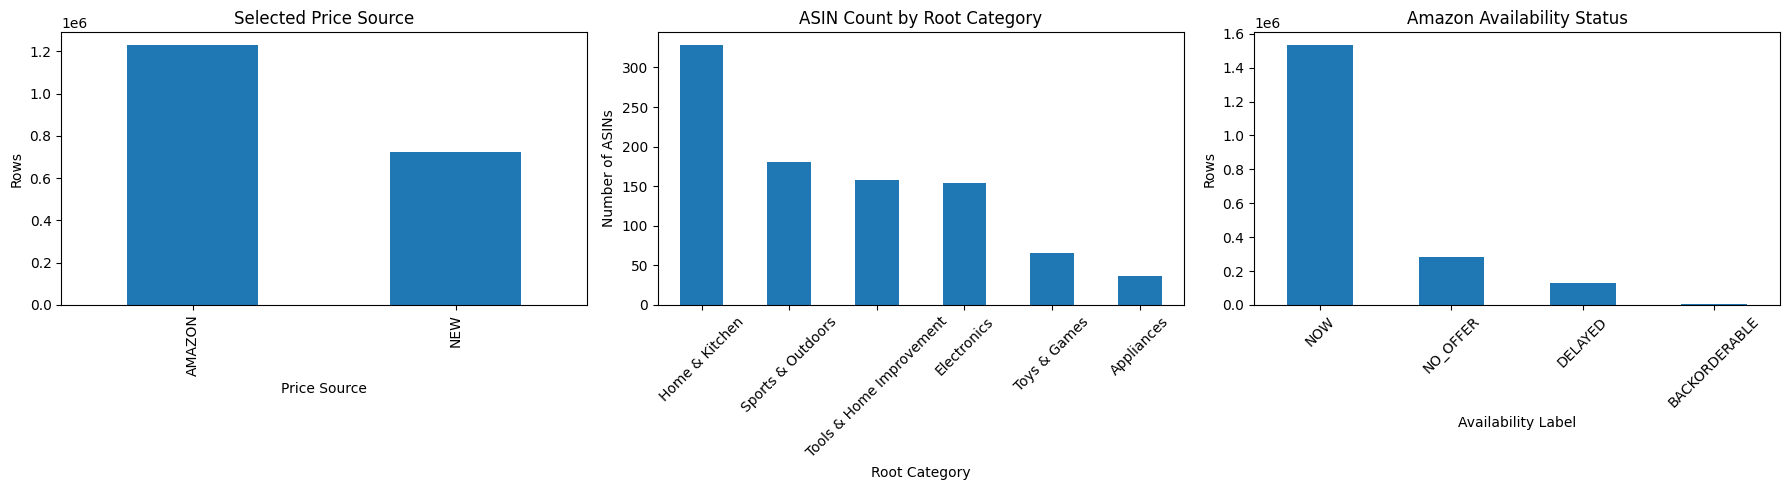

In [14]:
# Cell 6 - Visualise Key Processed Data Distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["price_source"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Selected Price Source")
axes[0].set_xlabel("Price Source")
axes[0].set_ylabel("Rows")

df.groupby("root_category")["asin"].nunique().sort_values(ascending=False).plot(kind="bar", ax=axes[1])
axes[1].set_title("ASIN Count by Root Category")
axes[1].set_xlabel("Root Category")
axes[1].set_ylabel("Number of ASINs")
axes[1].tick_params(axis="x", rotation=45)

df["availability_amazon_label"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Amazon Availability Status")
axes[2].set_xlabel("Availability Label")
axes[2].set_ylabel("Rows")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Distribution Interpretation

The cleaned dataset contains both Amazon-direct and lowest new-offer price observations. Most selected prices come from `AMAZON`, but a substantial number come from `NEW`, so retaining `price_source` is important for the model.

The Amazon availability status is mostly `NOW`, meaning the Amazon direct offer is in stock and shippable. However, the dataset also contains meaningful numbers of `NO_OFFER`, `DELAYED`, and `BACKORDERABLE` records. This confirms that availability-related fields should be treated as categorical status signals rather than continuous numeric variables.

In [15]:
# Cell 8 - Summarise Final Cleaning Outcome

cleaning_summary = pd.DataFrame({
    "Metric": [
        "Raw JSON files processed",
        "ASINs before quality filters",
        "ASINs after quality filters",
        "ASINs dropped",
        "Final rows",
        "Start date",
        "End date",
        "Minimum selected price",
        "Maximum selected price",
        "Average selected price",
        "Root categories",
        "Leaf categories"
    ],
    "Value": [
        len(raw_files),
        966,
        df["asin"].nunique(),
        966 - df["asin"].nunique(),
        len(df),
        df["date"].min().date(),
        df["date"].max().date(),
        f"${df['amazon_price'].min():.2f}",
        f"${df['amazon_price'].max():.2f}",
        f"${df['amazon_price'].mean():.2f}",
        df["root_category"].nunique(),
        df["leaf_category"].nunique()
    ]
})

cleaning_summary

,Metric,Value
0,Raw JSON files processed,966
1,ASINs before quality filters,966
2,ASINs after quality filters,922
3,ASINs dropped,44
4,Final rows,1951779
5,Start date,2015-01-01
6,End date,2026-06-01
7,Minimum selected price,$1.00
8,Maximum selected price,$1999.97
9,Average selected price,$83.75


## Final Cleaning Interpretation

The V2 cleaning process produced a modelling-ready daily dataset with 922 products and 1,951,779 rows.

The final dataset is suitable for the next feature engineering stage because:

- the selected modelling price, `amazon_price`, has no missing values
- unrealistic price values below $1 and above $2,000 were removed
- both `AMAZON` and `NEW` price histories were preserved separately
- `price_source` identifies whether each selected price came from Amazon direct price history or lowest new-offer price history
- sales rank is mostly available, with only 5.60% missing values
- `monthly_sold` is almost fully available and provides a useful demand/popularity signal
- Amazon availability status is available for all rows and has been mapped into readable labels
- product metadata such as brand, manufacturer, root category, and leaf category is retained

The main remaining limitation is `offer_count`, which has 31.17% missing values. This field should still be useful as an availability and marketplace-competition proxy, but feature engineering should handle its missingness carefully.

For modelling, `root_category` should be preferred over `leaf_category` as the main category feature because the raw exploration showed that leaf categories are highly sparse.

The cleaned dataset is now ready for feature engineering, including lag features, rolling statistics, calendar features, price-source indicators, availability indicators, and the future 14-day price-drop label.